# APS 7BM Time-resolved Radiography

This program reads DataGrabber oscilloscope files from APS 7BM and computes raster scan maps and spectra.
It's designed to handle very large, high resolution arrays.

    @author Daniel Duke <daniel.duke@monash.edu>
    @copyright (c) 2026 D.Duke
    @license GPL-3.0+
    @version 0.0.1
    @date 26/03/2026
    
    Multiphase Flow Laboratory
    Monash University, Australia


---
Time-Resolved Radiography of Cavitating Nozzle Flow

When: 08/04/2013
Where: 7-BM, APS, Argonne National Lab
Who: Duke, Powell
Detector: Pin Diode, Femto Amp, Yokogawa DLM2000 scope for the BIM and Pin Diode
	  Yokogawa SL1000 scope and Omega Process Controllers for P3,P4 and Massflow

Note:

Scan_*.dat.gz are DataGrabber files from the Windows PC.

The DLM2k scope was set at ~6 MS/s for 20 seconds with a 1 MHz lowpass filter on the PIN channel (1) and the BIM was in channel 3.
The SL1000 scope was set to record the transducer settings and the trigger signal at 1kHz, triggered from the DLM scope.

The Femto amp gain, the conversions from voltage to pressure etc. for the SL1000 readouts, and the conditions for each scan are written in the log book for Cycle_2013_1.

This is raw data; the time-resolved signal needs to be integrated over the orbit time (ie sum up the points over the orbit time).  At 271.554 kHz, the orbit time is 3.68250882us.

---

## Stage 1 . Convert DAT files to HDF5

In [1]:
import glob, os

dg_compressed_files = glob.glob('/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM/*.dat.gz')

file_path = os.path.dirname(dg_compressed_files[0])+'/'

In [18]:

# minor changes made to Alan's code to import, handle duplicate keys, and compressed input and output.
from Python_Library import DataGrabbertoHDF5_Multiprocess as DGtoHDF

DGtoHDF.file_path=file_path

# Process all .dat.gz files
for dg_file in dg_compressed_files:

    h5_file = os.path.basename(dg_file).replace('.dat.gz','.h5')
    print('='*105)
    if os.path.isfile(h5_file): 
        #os.remove(h5_file)
        print("Skipping %s (already exists)" % os.path.basename(h5_file))
    else:
        print(os.path.basename(dg_file))
        # fconvert_file wants only the basename, as abs path specified in file_path
        DGtoHDF.fconvert_file(os.path.basename(dg_file),h5_file)

print("Conversion complete.")

Scan_795.dat.gz
FileType=DataGrabberBinary X=-0.239000 Y=0.099950 NumberOfChannels=6 TimeStamp=2013-Apr-08_17:43:38 ClockTicks=1000000 BIM=2642 PINDiode=21727 I0_APD=0 APSRingCurrent=102.0581 GasBottlePressure(psig)=1168.00183 PSBarometricPressure(psia)=14.2254 7BMMonoEnergy(keV)=8.0019 AccumChargePressure=12.4215 DrainVesselPressure=0.6130 InputT=26.1041 OutputT=26.7989









FileType=DataGrabberBinary X=-0.202000 Y=0.099950 NumberOfChannels=6 TimeStamp=2013-Apr-08_17:44:44 ClockTicks=1000000 BIM=2637 PINDiode=21386 I0_APD=0 APSRingCurrent=101.8489 GasBottlePressure(psig)=1166.17075 PSBarometricPressure(psia)=14.2257 7BMMonoEnergy(keV)=8.0019 AccumChargePressure=12.3844 DrainVesselPressure=0.6169 InputT=26.2204 OutputT=26.7255









FileType=DataGrabberBinary X=-0.002000 Y=0.099950 NumberOfChannels=6 TimeStamp=2013-Apr-08_17:45:50 ClockTicks=1000000 BIM=2630 PINDiode=21945 I0_APD=0 APSRingCurrent=101.6404 GasBottlePressure(psig)=1166.01816 PSBarometricPressure(psia)=14.2260 7BMM

/Users/dduke/src/jupyterNotebooks/Research/TimeresolvedRadiography/Python_Library/readdatagrabber.py:186: RuntimeWarning: invalid value encountered in multiply
  self.data = scale_value * self.data + offset_value


Working on position # 1, position [-0.202, 0.09995]
Replicate # 0
Working on position # 2, position [-0.002, 0.09995]
Replicate # 0
Working on position # 3, position [0.198, 0.09995]
Replicate # 0
Working on position # 4, position [0.236, 0.09995]
Replicate # 0
Working on position # 5, position [-0.2395, 0.5999]
Replicate # 0
Working on position # 6, position [-0.202, 0.5999]
Replicate # 0
Working on position # 7, position [-0.002, 0.5999]
Replicate # 0
Working on position # 8, position [0.198, 0.5999]
Replicate # 0
Working on position # 9, position [0.236, 0.5999]
Replicate # 0
Working on position # 10, position [-0.2395, 1.19995]
Replicate # 0
Working on position # 11, position [-0.202, 1.19995]
Replicate # 0
Working on position # 12, position [-0.002, 1.19995]
Replicate # 0
Working on position # 13, position [0.198, 1.19995]
Replicate # 0
Working on position # 14, position [0.236, 1.19995]
Replicate # 0
Working on position # 15, position [-0.2395, 1.9999]
Replicate # 0
Working on po

---
## Stage 2. Bin the time-series and remove the bunch-charge variations

We just want one data point per synchrotron pulse to give ~6.5 MHz time resolution.

In [1]:
import h5py, os, glob, time
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

In [2]:
file_path='/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM'
hdf5_files = glob.glob(file_path+'/*.h5')

with h5py.File(hdf5_files[0],'r') as H:
    data = H['PINDiode'][0,:,:]
    print("PINDiode array size:",data.shape)
    for k in H['PINDiode'].attrs.keys():
        print ('\t',k, H['PINDiode'].attrs[k])
    dt = float(H['PINDiode'].attrs['TimeStep'])
    t0 = float(H['PINDiode'].attrs['FirstPointTime'])
    c_ = float(H['PINDiode'].attrs['Offset'])
    m_ = float(H['PINDiode'].attrs['Scale'])

# time axis
t=np.arange(len(data))*dt + t0

PINDiode array size: (125000000, 2)
	 BinaryDataType short
	 Channel 4
	 DAQDevice YokogawaScope2_710130_Ch1
	 DIMENSION_LABELS ['Location' 'Time' 'Replicates']
	 DynamicRangeBits 16
	 FPointer 16510941644
	 FirstPointTime 0.0
	 NumAverages None
	 Offset 0.23
	 RecordLength 125000000
	 Scale 3.125E-6
	 TimeStep 1.6E-7
	 UserDescription PINDiode
	 Volts Scale*ADCValue+Offset


In [3]:
import sys
cython_lib_dir='/Users/dduke/src/jupyterNotebooks/Research/TimeresolvedRadiography/Python_Library'
if not cython_lib_dir in sys.path:
    print("Added to sys.path")
    sys.path.insert(1, cython_lib_dir)

from Python_Library import ArrayBinModule

Added to sys.path


---

**def fbin_signal_fixed_time(input_array,delta_t,pulse_time=None,repeat_num=None,start_time=0)**

Function to read in signal, binning by fixed bin time bin_time.

Inputs:
- input_array: array of input data.
- delta_t: time period between measurement points in the original array.
- pulse_time: Initial estimate of the time between pulses.
- repeat_num: if the pulses have a repeating pattern, how many pulses per period.
- start_point: where should integration begin.

Outputs:
- output_data: binned signal 
- pulse_time: updated measurement of the time between pulses
- start_point * delta_t: where did we really begin integration

**def fbin_signal_by_pulse(input_array,delta_t,pulse_time=None,repeat_num=1,start_time=0)**

Bin a peaked signal with a regular period by each peak.  

Code finds the peak spacing.  Peaks need not be at integer spacing.

Inputs:
- input array: array of peaked input data.
- delta_t: time period between measurement points in the original array.
- pulse_time: Initial estimate of the time between pulses.
- repeat_num: if the pulses have a repeating pattern, how many pulses per period.
- start_time: where should integration begin.  Only here to match fbin_signal_fixed_time

Outputs:
- output_data: binned signal 
- pulse_time: updated measurement of the time between pulses
- start_point * delta_t: where did we really begin integration
    

In [18]:

pulse_time=1/271554./24.
repeat_num=24
start_time=dt*0

t0=time.time()
output_data, pulse_time, start_point = ArrayBinModule.fbin_signal_fixed_time(data[:,0].astype(np.float64),\
                                                                      dt,pulse_time,repeat_num,start_time)

print("Completed one timeseries in %f sec. (%i samples)" % (time.time()-t0, len(output_data)))

Completed one timeseries in 7.328517 sec. (130345917 samples)


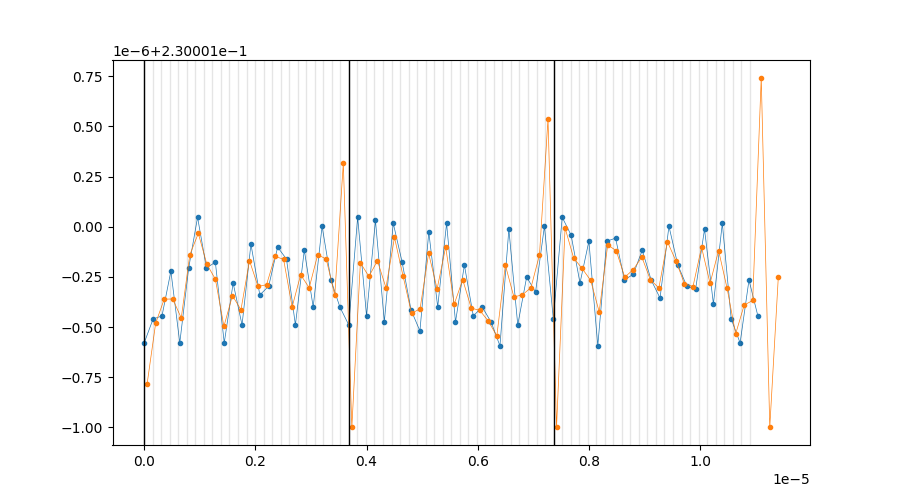

In [19]:
fig=plt.figure(figsize=(9,5))
plt.plot(t[:70], m_*data[:70,0]+c_,lw=.5,marker='.')

t_out = np.arange(start_point,start_point+len(output_data)*pulse_time,pulse_time)

plt.plot(t_out[:75], m_*output_data[:75]+c_,lw=.5,marker='.')

#plt.grid(alpha=.2);
#plt.ylim(0,data.max())
for n in range(3):
    plt.axvline(n*pulse_time*repeat_num,c='k',lw=1,alpha=1)
    for m in range(repeat_num):
        plt.axvline(n*pulse_time*repeat_num + m*pulse_time,c='k',lw=1,alpha=.1)

---
## Stage 3. Merge datasets so we have one per experimental condition

Using logbook information.

---
## Stage 4. Plot the time-average statistics

---
## Stage 5. Compute the spectra

---
## Stage 6. Plot the results

- Spectral integrals
- Transverse average spectra